## Автоэнкодер и их типы

In [1]:
import numpy as np
from keras.datasets import mnist
from keras.layers import Conv2D
%matplotlib inline
import matplotlib.pyplot as plt
from keras import losses
from keras import activations
from keras.layers import Input, Dense, Flatten, Reshape
from keras.models import Model
import tensorflow as tf
import datetime

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

### Сжимающий автоэнкодер

Для начала создадим наиболее простой (сжимающий, undercomplete) автоэнкодер с кодом малой размерности из двух полносвязных слоев: енкодера и декодера.

Так как интенсивность цвета нормирована на единицу, то активацию выходного слоя возьмем сигмоидой.

Напишем отдельные модели для энкодера, декодера и целого автоэнкодера. Для этого создадим экземпляры слоев и применим их один за другим, в конце все объединив в модели.

In [2]:
def create_dense_ae():
    # Размерность скрытого пространства
    encoding_dim = 49

    # Правило связывания слоев:
    # первая скобка - параметры текущего слоя
    # вторая скобка - переменная, которая отвечает за предыдущий слой

    # Энкодер
    # Входной слой
    # 28, 28, 1 - размерности строк, столбцов, фильтров (каналов) одной картинки
    input_img = Input(shape=(28, 28, 1))
    # Вспомогательный слой    
    middle_img = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1))(
        input_img)
    # Кодированное полносвязным слоем представление
    flat_img = Flatten()(middle_img)

    encoded = Dense(encoding_dim, activation='relu')(flat_img)

    # Декодер
    # Раскодированное другим полносвязным слоем изображение
    input_encoded = Input(shape=(encoding_dim,))
    flat_decoded = Dense(10*10, activation='sigmoid')(input_encoded)
    flat2_decoded = Dense(28*28, activation='sigmoid')(flat_decoded)
    decoded = Reshape((28, 28, 1))(flat2_decoded)

    # Модели: в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    encoder = Model(input_img, encoded, name="encoder")
    decoder = Model(input_encoded, decoded, name="decoder")
    autoencoder = Model(input_img, decoder(encoder(input_img)), name="autoencoder")
    return encoder, decoder, autoencoder

Создадим и скомпилируем модель (под компиляцией в данном случае понимается построение графа вычислений обратного распространения ошибки)

In [3]:
encoder, decoder, autoencoder = create_dense_ae()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

D:\programming\python\2025-NN-AI\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Посмотрим на число параметров

In [4]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 49)             │     2,119,985 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,625 (8.09 MB)

 Trainable params: 2,120,625 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │        79,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,184 (328.84 KB)

 Trainable params: 84,184 (328.84 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 49)             │     2,120,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        84,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,809 (8.41 MB)

 Trainable params: 2,204,809 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

Обучим теперь наш автоэнкодер

In [7]:
log_dir = "logs/autoencoder/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                callbacks=[tensorboard_callback],
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.2927 - val_loss: 0.2572
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.2402 - val_loss: 0.2181
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - loss: 0.2024 - val_loss: 0.1878
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 0.1768 - val_loss: 0.1659
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 0.1604 - val_loss: 0.1535
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 0.1506 - val_loss: 0.1457
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.1443 - val_loss: 0.1408
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.1399 - val_loss: 0.1369
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - loss: 0.1366 - val_loss: 0.1341
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - loss: 0.1339 - val_loss: 0.1316


Функция отрисовки цифр

In [8]:
def plot_digits(*args):
    args = [x.squeeze() for x in args]
    n = min([x.shape[0] for x in args])

    plt.figure(figsize=(2 * n, 2 * len(args)))
    for j in range(n):
        for i in range(len(args)):
            ax = plt.subplot(len(args), n, i * n + j + 1)
            plt.imshow(args[i][j])
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

    plt.show()

Закодируем несколько изображений и взглянем на пример кода

In [9]:
n = 10

imgs = x_test[:n]  # первые 10 картинок
encoded_imgs = encoder.predict(imgs, batch_size=n)  # получить скрытые значения (вектор 49 чисел) для первых 10 картинок
encoded_imgs[0]  # посмотреть на первую картинку (вектор значений)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([ 0.       ,  0.       , 20.511288 ,  0.       , 23.527294 ,
       16.0488   , 24.682602 ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       , 27.978045 ,
       17.4614   , 10.9087105,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       , 40.19531  ,  0.       , 24.815136 ,
        0.       , 13.154431 ,  0.       , 14.784229 ,  0.       ,
        0.       ,  0.       ,  0.       , 31.661354 ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       , 17.620464 ,
        0.       , 33.246223 ,  0.       , 33.6499   ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ], dtype=float32)

Декодируем эти коды и сравним с оригиналами

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


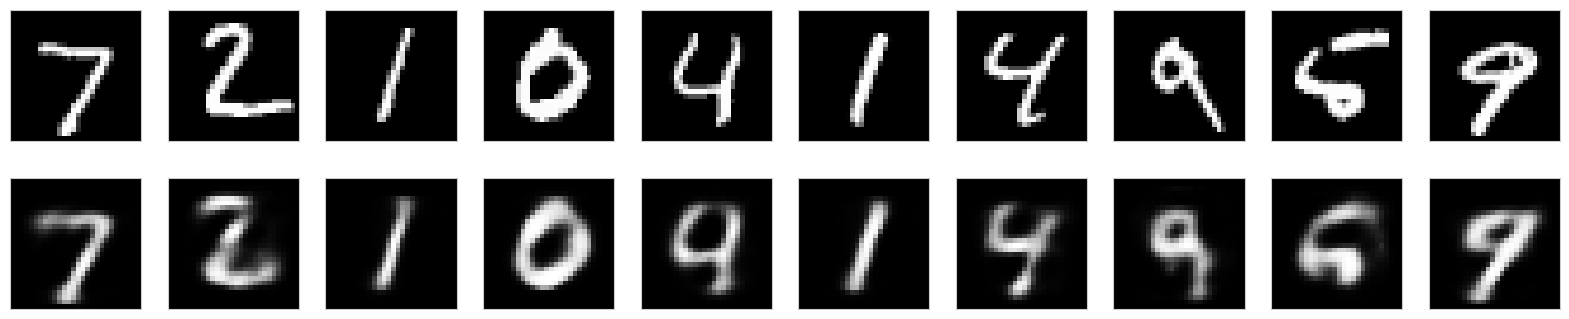

In [10]:
decoded_imgs = decoder.predict(encoded_imgs, batch_size=n)

plot_digits(imgs, decoded_imgs)  # исходные и обработанные картинки

### Задания

С использованием приведенных сведений студентам надлежит:

* обучить на MNIST автокодировщик (мы провели обучение на 10 эпохах, попробовать другое значение, можно ли лучше?);
* получить векторы всех изображений MNIST с выхода кодера;
* использовать полученные векторы в качестве входных для обучения нейронной сети – классификатора рукописных цифр;
* сравнить точности классификации, получаемые нейронной сетью, обученными на изображениях MNIST и на векторах, снятых с выхода кодера автокодировщика.

In [11]:
# Ваш код


In [ ]:
x_enc_train = encoder.predict(x_train,
                              batch_size=600)

In [ ]:
x_enc_test = encoder.predict(x_test, batch_size=len(x_test))

In [ ]:
encoding_dim = 49

def create_classifier():
    # Размерность скрытого пространства
    input_encoded = Input(shape=(encoding_dim,))
    dense1 = Dense(28, activation=activations.relu)(input_encoded)
    dense2 = Dense(128, activation=activations.relu)(dense1)
    dense3 = Dense(28, activation=activations.relu)(dense2)
    output_classes = Dense(10, activation=activations.softmax)(dense3)

    # Модели: в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    classifier = Model(input_encoded, output_classes, name="classifier")
    return classifier

In [ ]:
classifier = create_classifier()
classifier.compile(optimizer='adam', loss=losses.sparse_categorical_crossentropy, metrics=["accuracy"])

In [ ]:
classifier.summary()

In [ ]:
log_dir = "logs/classify/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
classifier.fit(x_enc_train, y_train,
                epochs=200,
                batch_size=256,
                shuffle=True,
                callbacks=[tensorboard_callback],
                validation_data=(x_enc_test, y_test))

In [ ]:
test_loss, test_accuracy = classifier.evaluate(x_enc_test, y_test, batch_size=256, verbose=2)

In [ ]:
x_autoencoder_train = autoencoder.predict(x_train,
                              batch_size=600)

In [ ]:
plot_digits(x_train[:20], x_autoencoder_train[:20])